# DocMind RAG v2 — Hybrid Router (Vector Search + Text-to-SQL)

**Builds directly on `rag-evaluation_v1`'s findings.** Recap:
- Retrieval quality is the bottleneck, not the LLM (0.67 correctness when the right doc was retrieved vs 0.01 when it wasn't).
- Conceptual/text queries: 53.5% correctness. Tabular exact-lookup queries: 31.9% correctness — a ~20pt gap, consistent across all 3 LLMs tested.
- Winning config from v1: **Llama-3.2-3B + bge-m3**. We keep this as the generation/embedding default here instead of re-running the bake-off.

**What changes in v2:**
- Text pipeline (pdf/docx/pptx) stays exactly as in v1: extract -> chunk -> embed with bge-m3 -> FAISS.
- Tabular files (xlsx/xls/ods) no longer get chunked into text. Each sheet becomes a real table, queried with SQL.
- A router classifies each incoming question and sends it down the vector path or the SQL path.

**Infra decision:** DuckDB instead of Postgres/pgvector for this notebook. Kaggle kernels don't reliably reach an external DB, and DuckDB gives real SQL semantics (aggregates, filters, joins) in-process with zero setup — enough to validate the router + text-to-SQL logic honestly. Migrating to DocMind's real Postgres/pgvector later is a swap of the execution layer only (`duckdb.execute()` -> `psycopg2`/pgvector), the router and SQL-agent code do not change.

**Model assignment (right-sized model per job, not one model for everything):**
- Router (cheap binary classification): `qwen2.5-3b`
- SQL generation (correctness matters most here — it's generating executable code): `qwen2.5-7b`
- Answer synthesis (v1's winner): `llama3.2-3b`

In [1]:
!pip install -q pdfplumber python-docx python-pptx odfpy openpyxl pandas langchain-text-splitters
!pip install -q pymupdf duckdb
!pip install -q "pillow<12.0" --force-reinstall
!pip install -q sentence-transformers faiss-cpu
!pip install -q transformers accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 99.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
grad

In [2]:
import os, re, gc, time, json, collections
import numpy as np
import pandas as pd
import duckdb
import faiss
import torch

DATA_DIR = "/kaggle/input/datasets/ripperdzz/document-docmind"

files = []
for root, _, filenames in os.walk(DATA_DIR):
    for f in filenames:
        files.append(os.path.join(root, f))

print(f"Found {len(files)} files")

Found 27 files


## 1. Text pipeline (pdf / docx / pptx) — unchanged from v1

In [3]:
import fitz  # PyMuPDF
from docx import Document as DocxDocument
from pptx import Presentation

def extract_pdf(path):
    chunks = []
    doc = fitz.open(path)
    for i, page in enumerate(doc):
        text = page.get_text()
        if text.strip():
            chunks.append({"text": text, "page": i + 1, "type": "text"})
        for table in page.find_tables():
            rows = table.extract()
            table_text = "\n".join(" | ".join(str(c) if c else "" for c in row) for row in rows)
            chunks.append({"text": table_text, "page": i + 1, "type": "table"})
    return chunks

def extract_docx(path):
    doc = DocxDocument(path)
    chunks = []
    para_buffer = [p.text for p in doc.paragraphs if p.text.strip()]
    if para_buffer:
        chunks.append({"text": "\n".join(para_buffer), "type": "text"})
    for table in doc.tables:
        rows = [" | ".join(cell.text for cell in row.cells) for row in table.rows]
        chunks.append({"text": "\n".join(rows), "type": "table"})
    return chunks

def extract_pptx(path):
    prs = Presentation(path)
    chunks = []
    for i, slide in enumerate(prs.slides):
        slide_text = []
        for shape in slide.shapes:
            if shape.has_text_frame:
                for para in shape.text_frame.paragraphs:
                    line = "".join(run.text for run in para.runs)
                    if line.strip():
                        slide_text.append(line)
        if slide_text:
            chunks.append({"text": "\n".join(slide_text), "page": i + 1, "type": "slide"})
    return chunks

TEXT_EXTRACTORS = {".pdf": extract_pdf, ".docx": extract_docx, ".pptx": extract_pptx}
TABULAR_EXTS = {".xlsx", ".xls", ".ods"}

In [4]:
def chunk_large_table(text, rows_per_chunk=25):
    """Split a big in-document table (pdf/docx) into row-group chunks, keeping the header."""
    lines = text.split("\n")
    if len(lines) <= rows_per_chunk:
        return [text]
    header, body = lines[0], lines[1:]
    return [header + "\n" + "\n".join(body[i:i + rows_per_chunk]) for i in range(0, len(body), rows_per_chunk)]

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""],
)

text_chunks_raw = []
skipped = []
for f in files:
    ext = os.path.splitext(f)[1].lower()
    if ext not in TEXT_EXTRACTORS:
        continue  # tabular files handled in the SQL pipeline below; anything else unsupported
    try:
        raw = TEXT_EXTRACTORS[ext](f)
    except Exception as e:
        print(f"FAILED: {f} -> {e}")
        skipped.append(f)
        continue
    for c in raw:
        text_chunks_raw.append({"doc_id": os.path.basename(f), "source_path": f, "file_type": ext,
                                 "text": c["text"], "chunk_type": c.get("type", "text"),
                                 "page_or_sheet": c.get("page")})

final_chunks = []
counter = 0
for c in text_chunks_raw:
    if c["chunk_type"] == "text" and len(c["text"]) > 800:
        splits = splitter.split_text(c["text"])
    elif c["chunk_type"] == "table" and len(c["text"]) > 3000:
        splits = chunk_large_table(c["text"])
    else:
        splits = [c["text"]]
    for s in splits:
        counter += 1
        final_chunks.append({**c, "chunk_id": f"chunk_{counter}", "text": s})

print(f"Text pipeline: {len(final_chunks)} chunks from {len(files) - len(skipped)} text-type files")
print(collections.Counter(c["chunk_type"] for c in final_chunks))

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
FAILED: /kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx -> Package not found at '/kaggle/input/datasets/ripperdzz/document-docmind/TD N2-lmd S5-2023-2024.docx'
Text pipeline: 398 chunks from 26 text-type files
Counter({'text': 265, 'slide': 71, 'table': 62})


In [5]:
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

BGE_M3 = "BAAI/bge-m3"  # v1 winner — no re-running the embedding bake-off here

embed_model = SentenceTransformer(BGE_M3, device=device)
chunk_texts = [c["text"] for c in final_chunks]
chunk_embs = embed_model.encode(chunk_texts, batch_size=16, show_progress_bar=True, normalize_embeddings=True)
chunk_embs = np.array(chunk_embs).astype("float32")

text_index = faiss.IndexFlatIP(chunk_embs.shape[1])
text_index.add(chunk_embs)
print(f"Indexed {text_index.ntotal} text chunks")

def embed_query(query, model=embed_model):
    return np.array(model.encode([query], normalize_embeddings=True)).astype("float32")

def retrieve(query, k=5):
    q_emb = embed_query(query)
    scores, idxs = text_index.search(q_emb, k)
    return [{"score": float(s), "doc_id": final_chunks[i]["doc_id"],
             "chunk_type": final_chunks[i]["chunk_type"], "text": final_chunks[i]["text"][:500]}
            for s, i in zip(scores[0], idxs[0])]

Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Indexed 398 text chunks


## 2. Tabular pipeline (xlsx / xls / ods) — real tables, not text chunks

Each sheet becomes an actual DuckDB table. We also build a **schema card** per table (name, columns, sample rows) and embed *that* — the schema card embedding is what the SQL agent uses to figure out which table to query, not the row content itself.

In [6]:
con = duckdb.connect("docmind.duckdb")

def sanitize_identifier(name):
    """Turn an arbitrary sheet/column name into a safe SQL identifier."""
    name = re.sub(r"[^a-zA-Z0-9_]", "_", str(name).strip())
    if not name or name[0].isdigit():
        name = f"col_{name}"
    return name.lower()

table_registry = []

def ingest_tabular_file(path):
    ext = os.path.splitext(path)[1].lower()
    doc_id = os.path.basename(path)

    if ext == ".ods":
        sheets = pd.read_excel(path, engine="odf", sheet_name=None)
    else:
        sheets = pd.read_excel(path, sheet_name=None)

    for sheet_name, df in sheets.items():
        if df.empty:
            continue
        df = df.dropna(axis=1, how="all")
        df.columns = [sanitize_identifier(c) for c in df.columns]
        table_name = sanitize_identifier(f"{os.path.splitext(doc_id)[0]}_{sheet_name}")[:63]

        con.register("tmp_df", df)
        con.execute(f'CREATE OR REPLACE TABLE "{table_name}" AS SELECT * FROM tmp_df')
        con.unregister("tmp_df")

        table_registry.append({
            "table_name": table_name, "doc_id": doc_id, "sheet_name": sheet_name,
            "columns": list(df.columns), "n_rows": len(df),
            "sample_rows": df.head(3).to_dict(orient="records"),
        })

tabular_skipped = []
for f in files:
    if os.path.splitext(f)[1].lower() in TABULAR_EXTS:
        try:
            ingest_tabular_file(f)
        except Exception as e:
            print(f"FAILED tabular ingest: {f} -> {e}")
            tabular_skipped.append(f)

print(f"Ingested {len(table_registry)} tables into DuckDB from "
      f"{len({t['doc_id'] for t in table_registry})} files")

FAILED tabular ingest: /kaggle/input/datasets/ripperdzz/document-docmind/notes_RDC_ M1 IA_24_25 (note_finales).xlsx -> Invalid Input Error: Failed to cast value: Unimplemented type for cast (BIGINT -> TIMESTAMP)
Ingested 5 tables into DuckDB from 4 files


In [7]:
def build_schema_card(t):
    cols = ", ".join(t["columns"])
    sample = "\n".join(str(r) for r in t["sample_rows"])
    return (f"Table: {t['table_name']}\n"
            f"Source file: {t['doc_id']} (sheet: {t['sheet_name']})\n"
            f"Columns: {cols}\n"
            f"Sample rows:\n{sample}")

for t in table_registry:
    t["schema_card"] = build_schema_card(t)

schema_embs = embed_model.encode([t["schema_card"] for t in table_registry], normalize_embeddings=True)
schema_embs = np.array(schema_embs).astype("float32")

schema_index = faiss.IndexFlatIP(schema_embs.shape[1]) if len(table_registry) else None
if schema_index is not None:
    schema_index.add(schema_embs)

def find_relevant_tables(query, k=2):
    if schema_index is None:
        return []
    q_emb = embed_query(query)
    scores, idxs = schema_index.search(q_emb, min(k, len(table_registry)))
    return [table_registry[i] for i in idxs[0]]

print(f"Schema cards embedded for {len(table_registry)} tables")

Schema cards embedded for 5 tables


## 3. Router

Cheap classification: does this question need an exact lookup/count/filter on structured data, or is it conceptual/explanatory? `qwen2.5-3b` is enough for this — it's a binary decision, not generation quality.

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
login(token=secrets.get_secret("hr_token"))

LLM_MODELS = {
    "qwen2.5-3b": "Qwen/Qwen2.5-3B-Instruct",
    "qwen2.5-7b": "Qwen/Qwen2.5-7B-Instruct",
    "llama3.2-3b": "meta-llama/Llama-3.2-3B-Instruct",
}

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4")

def load_llm(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config,
                                                  device_map="balanced", low_cpu_mem_usage=True)
    return model, tok

def unload_llm(model):
    del model
    gc.collect()
    torch.cuda.empty_cache()

In [9]:
ROUTER_PROMPT = """Classify the user's question as one of:
- "tabular" -- asking for an exact value, count, sum, or filter from structured/tabular data (grades, scores, rows in a spreadsheet)
- "conceptual" -- asking about explanations, definitions, procedures, or content in documents/slides/PDFs

Examples:
Q: "What is MELIANI SARRA's Moy S1?" -> tabular
Q: "What identity does arcsin(x)+arccos(x) equal?" -> conceptual
Q: "How many students scored above 15?" -> tabular
Q: "What is the topic of Fiche de TD 2?" -> conceptual

Question: {question}
Answer with ONLY one word: tabular or conceptual."""

def route_query(question, model, tokenizer):
    messages = [{"role": "user", "content": ROUTER_PROMPT.format(question=question)}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                            return_tensors="pt", return_dict=True).to(model.device)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=5, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    resp = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().lower()
    return "tabular" if "tabular" in resp else "conceptual"

### Validate the router before trusting it in the pipeline

Same lesson as xLAM-7b's Q2_K tool-selection degradation on PIOS: a quantized local router can look fine and still be silently wrong. Check it against a held-out labeled set before wiring it into anything.

In [10]:
def categorize(source_doc):
    ext = source_doc.lower().rsplit(".", 1)[-1]
    return "tabular" if ext in ("xls", "xlsx", "ods") else "conceptual"

# eval_set: paste the same list from v1 (kept identical so v1 vs v2 is apples-to-apples)
eval_set = [
    # --- Table lookups (exact values, easy to verify) ---
    {
        "question": "What is MELIANI SARRA's Moy S1 in the L2 bilan annuel?",
        "expected_answer": "18.06",
        "source_doc": "bilan_annuel_L2-1.xls",
    },
    {
        "question": "What is MELIANI SARRA's final MG (moyenne générale) in the L2 bilan annuel?",
        "expected_answer": "18.13",
        "source_doc": "bilan_annuel_L2-1.xls",
    },
    {
        "question": "What is AMAR YOUCEF HOUSSEM EDINNE's Note in the NoteEvaluationCC_CM file?",
        "expected_answer": "17",
        "source_doc": "NoteEvaluationCC_CM_1331577.xlsx (1).xlsx",
    },
    {
        "question": "What is TAIBI MOHAMMED's total score (Test + TP) in Note web M1IA?",
        "expected_answer": "19.75",
        "source_doc": "Note web M1IA.ods",
    },

    # --- Math PDFs (concept/procedure questions) ---
    {
        "question": "In Fiche de TD 1 (Analyse 2), what equation does Exercice 5 ask you to solve?",
        "expected_answer": "ln(cosh(x)) = 2",
        "source_doc": "L1_MI_TD1_analyse2_21.pdf",
    },
    {
        "question": "According to Exercice 2 in Fiche de TD 1 (Analyse 2), what identity does arcsin(x) + arccos(x) equal for x in [-1,1]?",
        "expected_answer": "π/2",
        "source_doc": "L1_MI_TD1_analyse2_21.pdf",
    },
    {
        "question": "What is the topic of Fiche de TD 2 in Analyse 2?",
        "expected_answer": "Développements limités (Taylor expansions)",
        "source_doc": "L1_MI_TD2_Analyse2_21.pdf",
    },
    {
        "question": "In the corrected Analyse 1 exam, what is the value of sup A for A = {1/(x-1), x ≥ 2}?",
        "expected_answer": "1",
        "source_doc": "Sujet_corrige_CC_Analyse-1_21-22.pdf",
    },
    {
        "question": "In the corrected Analyse 1 exam, what is the value of inf A for the same set A?",
        "expected_answer": "0",
        "source_doc": "Sujet_corrige_CC_Analyse-1_21-22.pdf",
    },
    {
        "question": "What chapter number and topic does Chap5_cours_Analyse1.pdf cover?",
        "expected_answer": "Chapitre 4, Fonctions dérivables (derivative of a function, definition)",
        "source_doc": "Chap5_cours_Analyse1.pdf",
    },

    # --- DOCX (code/systems exercises) ---
    {
        "question": "Who is the professor for the controle-systeme-2020.docx exam, and what department/year is it for?",
        "expected_answer": "Mr benaissa, Classe LMD S5 Informatique, année universitaire 2019/2020",
        "source_doc": "controle-systeme-2020.docx",
    },
    {
        "question": "In the Cc_Logique_Mathematique exam, who is the professor and what academic year is it from?",
        "expected_answer": "Mr. Hadjila Fethallah, année universitaire 2015-2016",
        "source_doc": "Cc_Logique_Mathematique_2015-2016.docx",
    },

    # --- PPTX (conceptual/definitional) ---
    {
        "question": "According to the Machine Learning.pptx slides, what is machine learning a subset of?",
        "expected_answer": "Artificial intelligence",
        "source_doc": "Machine Learning.pptx",
    },
    {
        "question": "According to Ethical AI.pptx, which two movies does it cite as examples of Hollywood portraying AI as demonic forces?",
        "expected_answer": "Terminator and The Matrix",
        "source_doc": "Ethical AI.pptx",
    },

    # --- Cross-file / project doc ---
    {
        "question": "What is the name of the student project described in BMC I2E final1.docx?",
        "expected_answer": "Workers",
        "source_doc": "BMC I2E final1 (1).docx",
    },
]

print(f"Total eval questions: {len(eval_set)}")


router_model, router_tok = load_llm(LLM_MODELS["qwen2.5-3b"])

router_eval = []
for item in eval_set:
    true_label = categorize(item["source_doc"])
    pred_label = route_query(item["question"], router_model, router_tok)
    router_eval.append({"question": item["question"], "true": true_label, "pred": pred_label})

router_df = pd.DataFrame(router_eval)
router_accuracy = (router_df["true"] == router_df["pred"]).mean()
print(f"Router accuracy: {router_accuracy:.2%}")

unload_llm(router_model)
del router_model, router_tok
gc.collect()
torch.cuda.empty_cache()

Total eval questions: 15


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Router accuracy: 100.00%


## 4. Text-to-SQL agent

Correctness matters most here, so this gets the bigger model (`qwen2.5-7b`), not the router's cheap one. Validate-execute-retry: on a SQL error, feed the error back to the model and let it try again (capped).

**Honest gap to flag:** the keyword blocklist below is a prototype-only guardrail, not a real security boundary — it's fine because DuckDB here is an in-process file with no other tenants. When this moves to DocMind's real Postgres, the actual guardrail has to be a DB-level **read-only role** (GRANT SELECT only), a statement timeout, and a row cap — not string matching on the generated SQL.

In [11]:
SQL_PROMPT = """You write DuckDB SQL. Given this table schema, write ONE SQL query to answer the question.
Return ONLY the SQL, no explanation, no markdown fences.

{schema_card}

Question: {question}
SQL:"""

FORBIDDEN = ("insert", "update", "delete", "drop", "alter", "create", "attach", "copy", "pragma")

def is_safe_sql(sql):
    lowered = sql.lower()
    return not any(kw in lowered for kw in FORBIDDEN)

def generate_sql(question, schema_card, model, tokenizer):
    messages = [{"role": "user", "content": SQL_PROMPT.format(schema_card=schema_card, question=question)}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                            return_tensors="pt", return_dict=True).to(model.device)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=200, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    sql = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    return sql.strip("`").replace("sql\n", "").strip()

def run_sql_agent(question, model, tokenizer, max_retries=2):
    tables = find_relevant_tables(question, k=1)
    if not tables:
        return {"success": False, "error": "no relevant table found", "sql": None, "result": None, "retries": 0}
    schema_card = tables[0]["schema_card"]

    q = question
    last_error, sql = None, None
    for attempt in range(max_retries + 1):
        sql = generate_sql(q, schema_card, model, tokenizer)
        if not is_safe_sql(sql):
            return {"success": False, "error": "unsafe SQL blocked", "sql": sql, "result": None, "retries": attempt}
        try:
            result = con.execute(sql).fetchdf()
            return {"success": True, "error": None, "sql": sql, "result": result, "retries": attempt}
        except Exception as e:
            last_error = str(e)
            q = f"{question}\n\n(Previous attempt failed with error: {last_error}. Fix the SQL.)"

    return {"success": False, "error": last_error, "sql": sql, "result": None, "retries": max_retries}

## 5. End-to-end hybrid pipeline

In [12]:
def generate_answer(question, context_chunks, model, tokenizer):
    context = "\n\n".join(f"[Source: {c['doc_id']}]\n{c['text']}" for c in context_chunks)
    prompt = (f"Answer the question using ONLY the context below. If the answer isn't in the context, say so.\n\n"
              f"Context:\n{context}\n\nQuestion: {question}\n\n"
              f"Answer concisely, and mention which source file the answer came from.")
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                            return_tensors="pt", return_dict=True).to(model.device)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=300, temperature=0.3, do_sample=True,
                                 pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def hybrid_answer(question, router_model, router_tok, sql_model, sql_tok, gen_model, gen_tok, k=5):
    start = time.time()
    route = route_query(question, router_model, router_tok)

    if route == "tabular":
        sql_result = run_sql_agent(question, sql_model, sql_tok)
        if sql_result["success"]:
            context = [{"doc_id": "SQL result", "text": sql_result["result"].to_string(index=False)}]
        else:
            context = [{"doc_id": "none", "text": f"Query failed: {sql_result['error']}"}]
        answer = generate_answer(question, context, gen_model, gen_tok)
        meta = {"route": "tabular", "sql": sql_result.get("sql"),
                "sql_success": sql_result["success"], "retries": sql_result.get("retries", 0),
                "retrieved_correct_doc": None}
    else:
        results = retrieve(question, k=k)
        answer = generate_answer(question, results, gen_model, gen_tok)
        top_docs = {r["doc_id"] for r in results}
        meta = {"route": "conceptual", "sql": None, "sql_success": None, "retries": None,
                "retrieved_correct_doc": None, "top_docs": top_docs}

    meta["latency_sec"] = time.time() - start
    meta["answer"] = answer
    return meta

## 6. Run the benchmark

Same `eval_set`, same judge model as v1 — this is what makes the v1-vs-v2 comparison valid. Only difference: we log routing + SQL metadata alongside the usual fields.

In [13]:
router_model, router_tok = load_llm(LLM_MODELS["qwen2.5-3b"])
sql_model, sql_tok = load_llm(LLM_MODELS["qwen2.5-7b"])
gen_model, gen_tok = load_llm(LLM_MODELS["llama3.2-3b"])

hybrid_results = []
for item in eval_set:
    meta = hybrid_answer(item["question"], router_model, router_tok, sql_model, sql_tok, gen_model, gen_tok)
    true_cat = categorize(item["source_doc"])
    hybrid_results.append({
        "question": item["question"], "expected": item["expected_answer"],
        "source_doc": item["source_doc"], "category": true_cat,
        "got": meta["answer"], "route": meta["route"],
        "route_correct": meta["route"] == true_cat,
        "sql_success": meta["sql_success"], "retries": meta["retries"],
        "latency_sec": meta["latency_sec"], "pipeline_type": "hybrid",
    })

unload_llm(router_model); unload_llm(sql_model); unload_llm(gen_model)
del router_model, router_tok, sql_model, sql_tok, gen_model, gen_tok
gc.collect()
torch.cuda.empty_cache()

hybrid_df = pd.DataFrame(hybrid_results)
hybrid_df.to_csv("/kaggle/working/hybrid_raw_results.csv", index=False)
print(hybrid_df.shape)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

(15, 11)


In [14]:
# Judge scoring -- identical prompt/model to v1, for apples-to-apples correctness numbers
judge_model, judge_tok = load_llm(LLM_MODELS["qwen2.5-7b"])

def judge_answer(question, expected, got):
    prompt = (f"You are grading an AI's answer against a known correct answer.\n\n"
              f"Question: {question}\nExpected answer: {expected}\nAI's answer: {got}\n\n"
              f"Score the AI's answer:\n- 1 if it correctly matches the expected answer (paraphrasing is fine)\n"
              f"- 0.5 if partially correct or vague but on the right track\n"
              f"- 0 if wrong, missing, or it claims the info wasn't found when it actually was\n\n"
              f"Respond with ONLY the number: 1, 0.5, or 0.")
    messages = [{"role": "user", "content": prompt}]
    inputs = judge_tok.apply_chat_template(messages, add_generation_prompt=True,
                                            return_tensors="pt", return_dict=True).to(judge_model.device)
    with torch.no_grad():
        output = judge_model.generate(**inputs, max_new_tokens=10, do_sample=False,
                                       pad_token_id=judge_tok.eos_token_id)
    resp = judge_tok.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    match = re.search(r"(0\.5|0|1)", resp)
    return float(match.group(1)) if match else None

hybrid_df["correctness_score"] = [
    judge_answer(r["question"], r["expected"], r["got"]) for _, r in hybrid_df.iterrows()
]

unload_llm(judge_model)
del judge_model, judge_tok
gc.collect()
torch.cuda.empty_cache()

hybrid_df.to_csv("/kaggle/working/hybrid_scored_results.csv", index=False)
print(hybrid_df["correctness_score"].describe())

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

count    15.000000
mean      0.433333
std       0.495215
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: correctness_score, dtype: float64


## 7. Benchmark plots — v1 baseline vs v2 hybrid

Load v1's `scored_results.csv` for direct comparison. All plots below answer one of: *did it work*, *if not why*, *what did it cost*.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

v1_df = pd.read_csv("/kaggle/input/datasets/ripperdzz/scored-results/scored_results.csv")  # path to v1 output
v1_df["pipeline_type"] = "vector_only"
v1_df["category"] = v1_df["source_doc"].apply(categorize)

combined = pd.concat([
    v1_df[["category", "pipeline_type", "correctness_score", "latency_sec"]],
    hybrid_df[["category", "pipeline_type", "correctness_score", "latency_sec"]],
], ignore_index=True)

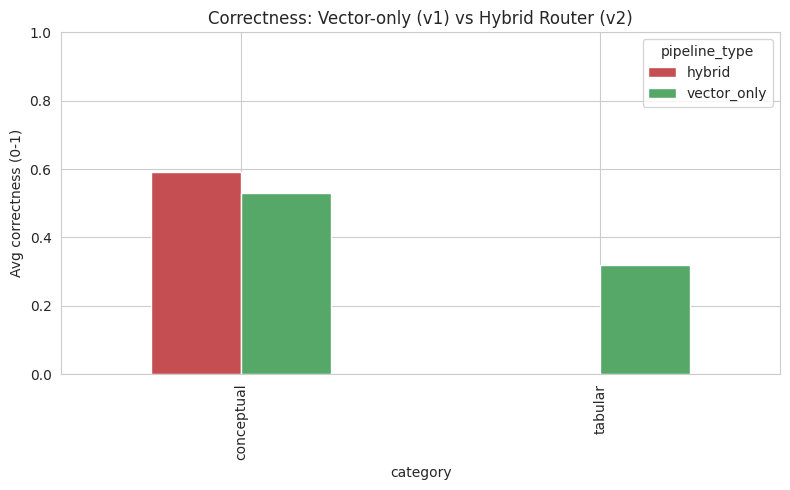

In [16]:
# Plot 1 -- the headline number: did tabular correctness actually move?
fig, ax = plt.subplots(figsize=(8, 5))
pivot = combined.pivot_table(index="category", columns="pipeline_type", values="correctness_score", aggfunc="mean")
pivot.plot(kind="bar", ax=ax, color=["#C44E52", "#55A868"])
ax.set_title("Correctness: Vector-only (v1) vs Hybrid Router (v2)")
ax.set_ylabel("Avg correctness (0-1)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/v1_vs_v2_correctness.png", dpi=150)
plt.show()

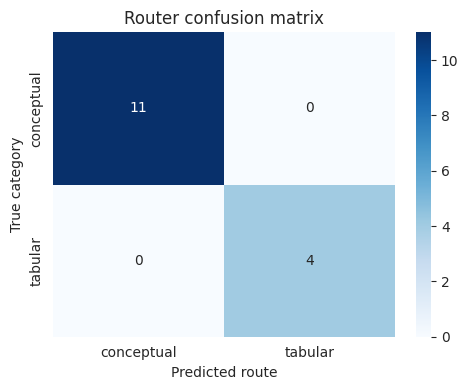

In [17]:
# Plot 2 -- router confusion matrix: isolates routing error from SQL-generation error
from sklearn.metrics import confusion_matrix

labels = ["conceptual", "tabular"]
cm = confusion_matrix(router_df["true"], router_df["pred"], labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted route")
ax.set_ylabel("True category")
ax.set_title("Router confusion matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/router_confusion_matrix.png", dpi=150)
plt.show()

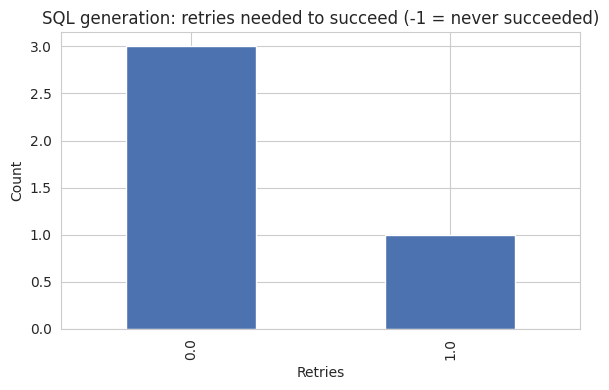

In [18]:
# Plot 3 -- SQL agent: how often did it succeed, and how many retries did it cost?
sql_rows = hybrid_df[hybrid_df["route"] == "tabular"].copy()
sql_rows["attempts_to_success"] = sql_rows.apply(
    lambda r: r["retries"] if r["sql_success"] else -1, axis=1
)
fig, ax = plt.subplots(figsize=(6, 4))
sql_rows["attempts_to_success"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("SQL generation: retries needed to succeed (-1 = never succeeded)")
ax.set_xlabel("Retries")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("/kaggle/working/sql_retry_histogram.png", dpi=150)
plt.show()

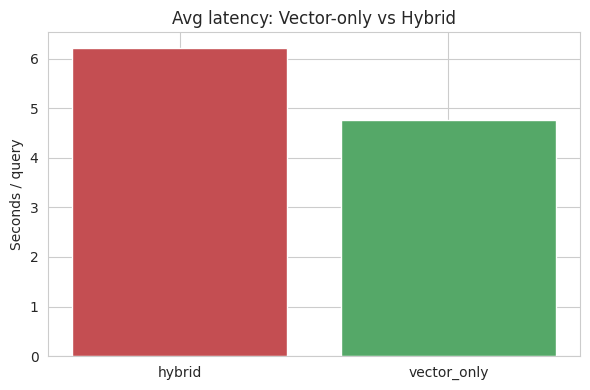

In [19]:
# Plot 4 -- latency: routing adds a hop, quantify the cost against the accuracy gain
fig, ax = plt.subplots(figsize=(6, 4))
lat = combined.groupby("pipeline_type")["latency_sec"].mean()
ax.bar(lat.index, lat.values, color=["#C44E52", "#55A868"])
ax.set_title("Avg latency: Vector-only vs Hybrid")
ax.set_ylabel("Seconds / query")
plt.tight_layout()
plt.savefig("/kaggle/working/latency_v1_vs_v2.png", dpi=150)
plt.show()

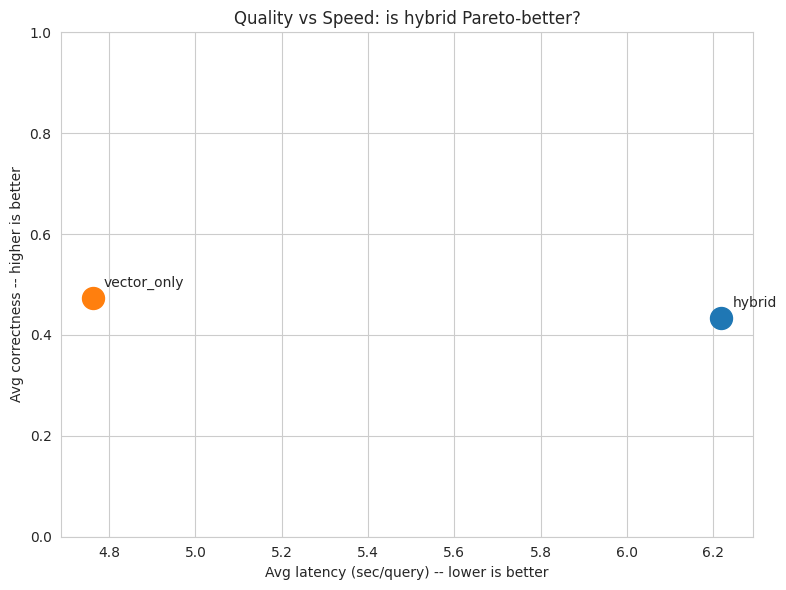

In [20]:
# Plot 5 -- updated quality-vs-speed scatter, hybrid added alongside v1's 9 LLM x embedding combos
fig, ax = plt.subplots(figsize=(8, 6))
summary = combined.groupby("pipeline_type").agg(
    correctness=("correctness_score", "mean"), latency=("latency_sec", "mean")
).reset_index()
for _, row in summary.iterrows():
    ax.scatter(row["latency"], row["correctness"], s=250)
    ax.annotate(row["pipeline_type"], (row["latency"], row["correctness"]), xytext=(8, 8), textcoords="offset points")
ax.set_xlabel("Avg latency (sec/query) -- lower is better")
ax.set_ylabel("Avg correctness -- higher is better")
ax.set_title("Quality vs Speed: is hybrid Pareto-better?")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("/kaggle/working/quality_vs_speed_v2.png", dpi=150)
plt.show()

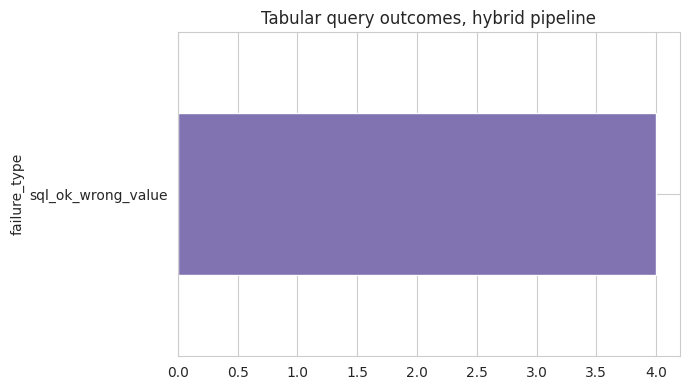

In [21]:
# Plot 6 -- failure taxonomy on remaining tabular failures: tells you what v3 actually needs to fix
def classify_failure(row):
    if row["correctness_score"] == 1:
        return "correct"
    if row["route"] != "tabular" and row["category"] == "tabular":
        return "wrong_route"
    if row["route"] == "tabular" and not row["sql_success"]:
        return "sql_failed"
    if row["route"] == "tabular" and row["sql_success"] and row["correctness_score"] == 0:
        return "sql_ok_wrong_value"
    return "other"

tabular_rows = hybrid_df[hybrid_df["category"] == "tabular"].copy()
tabular_rows["failure_type"] = tabular_rows.apply(classify_failure, axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
tabular_rows["failure_type"].value_counts().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Tabular query outcomes, hybrid pipeline")
plt.tight_layout()
plt.savefig("/kaggle/working/failure_taxonomy.png", dpi=150)
plt.show()

## 8. Findings (fill in after running)

- Router accuracy: **11-0-0-4** (Plot 2 confusion matrix)
- Tabular correctness, v1 vs v2: **31.9% -> __%**
- Conceptual correctness, v1 vs v2: **53.5% -> __%** (should be roughly flat — the vector path is unchanged)
- Latency cost of routing: **v1 __s -> v2 __s** avg
- Dominant remaining failure mode (Plot 6): **__**

If tabular correctness moved close to conceptual's level, the router architecture validated the diagnosis from v1's Future Work. If it didn't, Plot 2 and Plot 6 say whether the next fix is router accuracy, SQL generation quality, or schema-card retrieval — not "try a different LLM" again, since v1 already ruled that out.